In [1]:
import pandas as pd
import numpy as np
from lstm_dos import lstm_seq2seq
import torch
import matplotlib.pyplot as plt

In [2]:
file_path = "mid_datav1.csv"

In [3]:
df = pd.read_csv(file_path)

In [4]:
df.head()

,Unnamed: 0,MSG_TYPE,MMSI,NAME,IMO_NUMBER,CALL_SIGN,LAT_AVG,LON_AVG,PERIOD,SPEED_KNOTS,...,time_diff,cog_diff,new_voyage,voyage_id,geometry,in_channel_north,in_channel_south,location,num_pings,include
0,67,1,205089000,DICKENS,9898553.0,ONKZ,21.908479,-76.971564,2023-03-01 08:25:00,13.4,...,1200.0,2.0,True,13_205089000,POINT (-76.971564 21.908479),False,False,east,5,False
1,68,1,205089000,DICKENS,9898553.0,ONKZ,21.901958,-76.959594,2023-03-01 08:30:00,13.2,...,300.0,4.3,False,13_205089000,POINT (-76.959594 21.901958),False,False,east,5,False
2,69,1,205089000,DICKENS,9898553.0,ONKZ,21.895055,-76.938755,2023-03-01 08:35:00,13.2,...,300.0,6.5,False,13_205089000,POINT (-76.938755 21.895055),False,False,east,5,False
3,70,1,205089000,DICKENS,9898553.0,ONKZ,21.876328,-76.888575,2023-03-01 08:45:00,13.4,...,600.0,2.0,False,13_205089000,POINT (-76.888575 21.876328),False,False,east,5,False
4,71,1,205089000,DICKENS,9898553.0,ONKZ,21.872654,-76.878911,2023-03-01 08:50:00,13.4,...,300.0,0.2,False,13_205089000,POINT (-76.878911 21.872654),False,False,east,5,False


In [5]:
print(df.columns)

Index(['Unnamed: 0', 'MSG_TYPE', 'MMSI', 'NAME', 'IMO_NUMBER', 'CALL_SIGN',
       'LAT_AVG', 'LON_AVG', 'PERIOD', 'SPEED_KNOTS', 'COG_DEG', 'HEADING_DEG',
       'NAV_STATUS', 'NAV_SENSOR', 'SHIP_AND_CARGO_TYPE', 'DRAUGHT',
       'DRAUGHT.1', 'DIM_BOW', 'DIM_STERN', 'DIM_PORT', 'DIM_STARBOARD',
       'DESTINATION', 'MMSI_COUNTRY_CD', 'RECEIVER', 'BEAM', 'LENGTH',
       'CHANNEL_SIDE', 'time_diff', 'cog_diff', 'new_voyage', 'voyage_id',
       'geometry', 'in_channel_north', 'in_channel_south', 'location',
       'num_pings', 'include'],
      dtype='str')


In [6]:
df = df[['MMSI', 'LAT_AVG', 'LON_AVG', 'PERIOD', 'SPEED_KNOTS', 'COG_DEG', 'HEADING_DEG', 'voyage_id']]

In [7]:
df['TIME'] = pd.to_datetime(df['PERIOD'])
df = df.rename(columns = {'LAT_AVG':'LAT', 'LON_AVG':'LON', 'SPEED_KNOTS':'SPEED', 'COG_DEG':'COG', 'HEADING_DEG':'HEADING'})

print(df.dtypes)

MMSI                  int64
LAT                 float64
LON                 float64
PERIOD                  str
SPEED               float64
COG                 float64
HEADING             float64
voyage_id               str
TIME         datetime64[us]
dtype: object


In [8]:
print(len(df))
df = df.dropna()

44521


In [9]:
print(len(df))

42883


In [10]:
df.head()

,MMSI,LAT,LON,PERIOD,SPEED,COG,HEADING,voyage_id,TIME
0,205089000,21.908479,-76.971564,2023-03-01 08:25:00,13.4,121.0,119.0,13_205089000,2023-03-01 08:25:00
1,205089000,21.901958,-76.959594,2023-03-01 08:30:00,13.2,116.7,111.0,13_205089000,2023-03-01 08:30:00
2,205089000,21.895055,-76.938755,2023-03-01 08:35:00,13.2,110.2,108.0,13_205089000,2023-03-01 08:35:00
3,205089000,21.876328,-76.888575,2023-03-01 08:45:00,13.4,112.2,109.0,13_205089000,2023-03-01 08:45:00
4,205089000,21.872654,-76.878911,2023-03-01 08:50:00,13.4,112.0,108.0,13_205089000,2023-03-01 08:50:00


In [11]:
df['dt'] = df['TIME'].diff().dt.total_seconds()
df = df.dropna().reset_index(drop=True)


In [12]:
df.head()

,MMSI,LAT,LON,PERIOD,SPEED,COG,HEADING,voyage_id,TIME,dt
0,205089000,21.901958,-76.959594,2023-03-01 08:30:00,13.2,116.7,111.0,13_205089000,2023-03-01 08:30:00,300.0
1,205089000,21.895055,-76.938755,2023-03-01 08:35:00,13.2,110.2,108.0,13_205089000,2023-03-01 08:35:00,300.0
2,205089000,21.876328,-76.888575,2023-03-01 08:45:00,13.4,112.2,109.0,13_205089000,2023-03-01 08:45:00,600.0
3,205089000,21.872654,-76.878911,2023-03-01 08:50:00,13.4,112.0,108.0,13_205089000,2023-03-01 08:50:00,300.0
4,205089000,22.547895,-78.097770,2023-09-27 14:10:00,12.9,121.1,121.0,20_205089000,2023-09-27 14:10:00,18163200.0


In [13]:
df['cog_rad'] = np.deg2rad(df['COG'])
df['cog_sin'] = np.sin(df['cog_rad'])
df['cog_cos'] = np.cos(df['cog_rad'])

df['hdg_rad'] = np.deg2rad(df['HEADING'])
df['hdg_sin'] = np.sin(df['hdg_rad'])
df['hdg_cos'] = np.cos(df['hdg_rad'])


In [14]:
df['dlat'] = df['LAT'].diff()
df['dlon'] = df['LON'].diff()

df = df.dropna().reset_index(drop=True)


In [15]:
df.head()

,MMSI,LAT,LON,PERIOD,SPEED,COG,HEADING,voyage_id,TIME,dt,cog_rad,cog_sin,cog_cos,hdg_rad,hdg_sin,hdg_cos,dlat,dlon
0,205089000,21.895055,-76.938755,2023-03-01 08:35:00,13.2,110.2,108.0,13_205089000,2023-03-01 08:35:00,300.0,1.923353,0.938493,-0.345298,1.884956,0.951057,-0.309017,-0.006903,0.020839
1,205089000,21.876328,-76.888575,2023-03-01 08:45:00,13.4,112.2,109.0,13_205089000,2023-03-01 08:45:00,600.0,1.958259,0.925871,-0.377841,1.902409,0.945519,-0.325568,-0.018727,0.050180
2,205089000,21.872654,-76.878911,2023-03-01 08:50:00,13.4,112.0,108.0,13_205089000,2023-03-01 08:50:00,300.0,1.954769,0.927184,-0.374607,1.884956,0.951057,-0.309017,-0.003674,0.009664
3,205089000,22.547895,-78.097770,2023-09-27 14:10:00,12.9,121.1,121.0,20_205089000,2023-09-27 14:10:00,18163200.0,2.113594,0.856267,-0.516533,2.111848,0.857167,-0.515038,0.675241,-1.218859
4,205089000,22.523830,-78.055422,2023-09-27 14:20:00,12.9,121.6,122.0,20_205089000,2023-09-27 14:20:00,600.0,2.122320,0.851727,-0.523986,2.129302,0.848048,-0.529919,-0.024065,0.042348


In [16]:
vessels = df['MMSI'].unique()

splitter = int(len(vessels) * 0.9)

train_voyages = vessels[:splitter]
test_voyages  = vessels[splitter:]

df_train = df[df['MMSI'].isin(train_voyages)].copy()
df_test  = df[df['MMSI'].isin(test_voyages)].copy()


print(len(df_train)/len(df))
print(len(df_test)/len(df))
print(len(df_train))
print(len(df_test))



0.8372006249854248
0.16279937501457523
35900
6981


In [17]:
vessels = df['MMSI'].unique()

# Shuffle for randomness (VERY important)
rng = np.random.default_rng(42)
rng.shuffle(vessels)

n_total = len(vessels)

# 10% test
test_split = int(n_total * 0.9)

train_val_vessels = vessels[:test_split]
test_vessels      = vessels[test_split:]

# Now split train_val into train + val
val_frac_of_train = 0.2   # 20% of the 90%
val_split = int(len(train_val_vessels) * (1 - val_frac_of_train))

train_vessels = train_val_vessels[:val_split]
val_vessels   = train_val_vessels[val_split:]

# Create DataFrames
df_train = df[df['MMSI'].isin(train_vessels)].copy()
df_val   = df[df['MMSI'].isin(val_vessels)].copy()
df_test  = df[df['MMSI'].isin(test_vessels)].copy()

# Diagnostics
print("Train %:", len(df_train)/len(df))
print("Val %:",   len(df_val)/len(df))
print("Test %:",  len(df_test)/len(df))

print("Train rows:", len(df_train))
print("Val rows:",   len(df_val))
print("Test rows:",  len(df_test))

Train %: 0.7505188778246776
Val %: 0.1706583335276696
Test %: 0.07882278864765281
Train rows: 32183
Val rows: 7318
Test rows: 3380


In [18]:
def make_windows_from_df(
    df: pd.DataFrame,
    feature_cols,
    target_cols,
    seq_len: int = 20,
    target_len: int = 5,
    mmsi_col: str = "MMSI",
    time_col: str = "TIME"
):
    """
    Returns:
      X: torch.FloatTensor  (seq_len,  N, n_features)
      Y: torch.FloatTensor  (target_len, N, n_targets)
    """
    df = df.copy()
    df[time_col] = pd.to_datetime(df[time_col])

    X_list = []
    Y_list = []

    for mmsi, g in df.groupby(mmsi_col):
        g = g.sort_values(time_col).reset_index(drop=True)

        feats = g[feature_cols].to_numpy(dtype=np.float32)
        targs = g[target_cols].to_numpy(dtype=np.float32)

        n = len(g)
        if n < seq_len + target_len:
            continue

        for i in range(n - (seq_len + target_len) + 1):
            X_list.append(feats[i : i + seq_len])
            Y_list.append(targs[i + seq_len : i + seq_len + target_len])

    if len(X_list) == 0:
        raise ValueError("No windows created. Increase data or reduce seq_len/target_len.")

    X = torch.from_numpy(np.stack(X_list, axis=0))  # (N, seq_len, n_features)
    Y = torch.from_numpy(np.stack(Y_list, axis=0))  # (N, target_len, 2)

    # Your model expects (seq_len, batch, features)
    X = X.permute(1, 0, 2).contiguous()  # (seq_len, N, n_features)
    Y = Y.permute(1, 0, 2).contiguous()  # (target_len, N, 2)

    return X, Y

In [ ]:
feature_cols = ["LAT","LON","SPEED","dt","cog_sin","cog_cos","hdg_sin","hdg_cos"]
target_cols  = ["LAT","LON"]

seq_len = 20
target_len = 5

X_train, Y_train = make_windows_from_df(df_train, feature_cols, target_cols, seq_len=seq_len, target_len=target_len)
X_test,  Y_test  = make_windows_from_df(df_test,  feature_cols, target_cols, seq_len=seq_len, target_len=target_len)

print("X_train:", X_train.shape, "Y_train:", Y_train.shape)
print("X_test: ", X_test.shape,  "Y_test: ", Y_test.shape)

X_train: torch.Size([20, 18478, 8]) Y_train: torch.Size([5, 18478, 2])
X_test:  torch.Size([20, 1624, 8]) Y_test:  torch.Size([5, 1624, 2])


In [20]:
import math

def rollout_recursive(model, X, target_len, batch_size=64):
    """
    X: (seq_len, N, n_features)
    returns preds: (target_len, N, 2)
    """
    device = next(model.parameters()).device
    X = X.to(device)

    seq_len, N, _ = X.shape
    preds = torch.zeros(target_len, N, 2, device=device)

    lat_i, lon_i = 0, 1
    n_batches = math.ceil(N / batch_size)

    model.eval()
    with torch.no_grad():
        for b in range(n_batches):
            start = b * batch_size
            end = min(start + batch_size, N)
            bs = end - start

            xb = X[:, start:end, :]  # (seq_len, bs, n_features)

            h0, c0 = model.encoder.init_hidden(bs)
            enc_hidden = (h0.to(device), c0.to(device))

            _, enc_hidden = model.encoder(xb)

            dec_in = xb[-1, :, [lat_i, lon_i]]  # (bs, 2)
            dec_hid = enc_hidden

            outb = torch.zeros(target_len, bs, 2, device=device)
            for t in range(target_len):
                dec_out, dec_hid = model.decoder(dec_in, dec_hid)
                outb[t] = dec_out
                dec_in = dec_out

            preds[:, start:end, :] = outb

    return preds

In [21]:
EARTH_R_M = 6371000.0

def haversine_meters_torch(lat1, lon1, lat2, lon2):
    lat1 = torch.deg2rad(lat1); lon1 = torch.deg2rad(lon1)
    lat2 = torch.deg2rad(lat2); lon2 = torch.deg2rad(lon2)
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = torch.sin(dlat/2)**2 + torch.cos(lat1)*torch.cos(lat2)*torch.sin(dlon/2)**2
    c = 2 * torch.atan2(torch.sqrt(a), torch.sqrt(1 - a))
    return EARTH_R_M * c

def metrics_meters(pred_latlon, true_latlon):
    pred_lat, pred_lon = pred_latlon[..., 0], pred_latlon[..., 1]
    true_lat, true_lon = true_latlon[..., 0], true_latlon[..., 1]
    d = haversine_meters_torch(pred_lat, pred_lon, true_lat, true_lon)  # (target_len, N)

    mae = d.mean().item()
    mse = (d**2).mean().item()
    rmse = float(np.sqrt(mse))

    per_step_mae = d.mean(dim=1).detach().cpu().numpy()
    per_step_rmse = torch.sqrt((d**2).mean(dim=1)).detach().cpu().numpy()

    return mae, mse, rmse, per_step_mae, per_step_rmse

def rollout_recursive(model, X, target_len, batch_size=64):
    device = next(model.parameters()).device
    X = X.to(device)

    seq_len, N, _ = X.shape
    preds = torch.zeros(target_len, N, 2, device=device)

    lat_i, lon_i = 0, 1
    n_batches = math.ceil(N / batch_size)

    model.eval()
    with torch.no_grad():
        for b in range(n_batches):
            start = b * batch_size
            end = min(start + batch_size, N)
            bs = end - start

            xb = X[:, start:end, :]

            enc_hidden = model.encoder.init_hidden(bs, device)

            _, enc_hidden = model.encoder(xb)

            dec_in = xb[-1, :, [lat_i, lon_i]]
            dec_hid = enc_hidden

            outb = torch.zeros(target_len, bs, 2, device=device)
            for t in range(target_len):
                dec_out, dec_hid = model.decoder(dec_in, dec_hid)
                outb[t] = dec_out
                dec_in = dec_out

            preds[:, start:end, :] = outb

    return preds

In [22]:
target_len_list = [1, 5, 10, 15, 20]
seq_len = 20

X_train_dict, Y_train_dict = {}, {}
X_val_dict,   Y_val_dict   = {}, {}
X_test_dict,  Y_test_dict  = {}, {}

for tl in target_len_list:
    X_train_dict[tl], Y_train_dict[tl] = make_windows_from_df(
        df_train, feature_cols, target_cols,
        seq_len=seq_len, target_len=tl
    )

    X_val_dict[tl], Y_val_dict[tl] = make_windows_from_df(
        df_val, feature_cols, target_cols,
        seq_len=seq_len, target_len=tl
    )

    X_test_dict[tl], Y_test_dict[tl] = make_windows_from_df(
        df_test, feature_cols, target_cols,
        seq_len=seq_len, target_len=tl
    )

# sanity check
for tl in target_len_list:
    print(tl, X_train_dict[tl].shape, Y_train_dict[tl].shape)

1 torch.Size([20, 19827, 8]) torch.Size([1, 19827, 2])
5 torch.Size([20, 18478, 8]) torch.Size([5, 18478, 2])
10 torch.Size([20, 17025, 8]) torch.Size([10, 17025, 2])
15 torch.Size([20, 15783, 8]) torch.Size([15, 15783, 2])
20 torch.Size([20, 14742, 8]) torch.Size([20, 14742, 2])


In [26]:
import itertools
from pathlib import Path

teacher_forcing_ratio_list = [.2, .3, .4, .5, .6, .7]
learning_rate_list = [.01, .04, .06, .08, .1]

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
out_dir = Path("grid_models")
out_dir.mkdir(exist_ok=True)

rows = []

for target_len, tfr, lr in itertools.product(target_len_list, teacher_forcing_ratio_list, learning_rate_list):

    X_train = X_train_dict[target_len]
    Y_train = Y_train_dict[target_len]
    X_val   = X_val_dict[target_len]
    Y_val   = Y_val_dict[target_len]
    X_test  = X_test_dict[target_len]
    Y_test  = Y_test_dict[target_len]

    print(f"\nCombo: target_len={target_len}, tfr={tfr}, lr={lr}")

    model = lstm_seq2seq(input_size=X_train.shape[2], hidden_size=128).to(device)

    hist = model.train_model(
        X_train, Y_train,
        target_len=target_len,
        batch_size=64,
        val_input_tensor=X_val,          
        val_target_tensor=Y_val,
        max_epochs=500,
        training_prediction="teacher_forcing",
        teacher_forcing_ratio=tfr,
        learning_rate=lr,
        patience=10,
        save_path=None
    )

    preds = rollout_recursive(model, X_test, target_len, batch_size=64)
    mae_m, mse_m2, rmse_m, per_step_mae, per_step_rmse = metrics_meters(preds, Y_test.to(device))

    model_path = out_dir / f"seq2seq_tlen{target_len}_tfr{tfr}_lr{lr}.pt"
    torch.save(model.state_dict(), model_path)

    rows.append({
        "target_len": target_len,
        "teacher_forcing_ratio": tfr,
        "learning_rate": lr,
        "MAE_m": mae_m,
        "MSE_m2": mse_m2,
        "RMSE_m": rmse_m,
        "best_val_loss": hist["best_val_loss"],
        "model_path": str(model_path),
        "per_step_MAE_m": ",".join(f"{x:.2f}" for x in per_step_mae),
        "per_step_RMSE_m": ",".join(f"{x:.2f}" for x in per_step_rmse),
    })

results_df = pd.DataFrame(rows)


Combo: target_len=1, tfr=0.2, lr=0.01


  2%|▏         | 11/500 [00:20<14:54,  1.83s/it, no_improve=10, train=0.3622, val=0.3684]



Combo: target_len=1, tfr=0.2, lr=0.04


  3%|▎         | 17/500 [00:28<13:43,  1.70s/it, no_improve=10, train=0.5923, val=0.5308]



Combo: target_len=1, tfr=0.2, lr=0.06


...

  4%|▍         | 21/500 [03:14<1:14:00,  9.27s/it, no_improve=10, train=0.5877, val=0.4459]



Combo: target_len=20, tfr=0.7, lr=0.08


  6%|▌         | 29/500 [04:27<1:12:20,  9.22s/it, no_improve=10, train=0.7565, val=0.3315]



Combo: target_len=20, tfr=0.7, lr=0.1


  3%|▎         | 14/500 [02:16<1:19:08,  9.77s/it, no_improve=10, train=0.6569, val=1.2622]


In [25]:
import itertools
from pathlib import Path


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
out_dir = Path("grid_models")
out_dir.mkdir(exist_ok=True)

X_train = X_train_dict[15]
Y_train = Y_train_dict[15]
X_val   = X_val_dict[15]
Y_val   = Y_val_dict[15]
X_test  = X_test_dict[15]
Y_test  = Y_test_dict[15]


model = lstm_seq2seq(input_size=X_train.shape[2], hidden_size=128).to(device)

best_model = model.train_model(
        X_train, Y_train,
        target_len=15,
        batch_size=64,
        val_input_tensor=X_val,
        val_target_tensor=Y_val,
        max_epochs=500,
        training_prediction="teacher_forcing",
        teacher_forcing_ratio=.3,
        learning_rate=.04,
        patience=10,
        save_path=None
    )

  5%|▌         | 25/500 [03:16<1:02:12,  7.86s/it, no_improve=10, train=0.4979, val=0.6717]


In [ ]:
results_df.head()

,target_len,teacher_forcing_ratio,learning_rate,MAE_m,MSE_m2,RMSE_m,best_val_loss,model_path,per_step_MAE_m,per_step_RMSE_m
0,1,0.2,0.01,67482.093750,6.429698e+09,80185.397972,0.313530,grid_models\seq2seq_tlen1_tfr0.2_lr0.01.pt,67482.09,80185.40
1,1,0.2,0.04,71709.984375,6.707603e+09,81899.960049,0.313974,grid_models\seq2seq_tlen1_tfr0.2_lr0.04.pt,71709.98,81899.96
2,1,0.2,0.06,67680.195312,6.451174e+09,80319.203183,0.316244,grid_models\seq2seq_tlen1_tfr0.2_lr0.06.pt,67680.20,80319.20
3,1,0.2,0.08,67588.921875,6.474694e+09,80465.484178,0.318104,grid_models\seq2seq_tlen1_tfr0.2_lr0.08.pt,67588.92,80465.48
4,1,0.2,0.10,68202.656250,6.413708e+09,80085.627774,0.308857,grid_models\seq2seq_tlen1_tfr0.2_lr0.1.pt,68202.66,80085.62


In [30]:
target_len_1_df = results_df[results_df["target_len"] == 1]
target_len_5_df = results_df[results_df["target_len"] == 5]
target_len_10_df = results_df[results_df["target_len"] == 10]
target_len_15_df = results_df[results_df["target_len"] == 15]
target_len_20_df = results_df[results_df["target_len"] == 20]

In [ ]:
fig, axes = plt.supblots(1, 5, figsize=(20, 4))

for i in range(5):
    axes[i].scatter(target_len_1_df[i]["MAE_m"])

In [31]:
results_df.to_csv("lstm_results.csv", index=False)

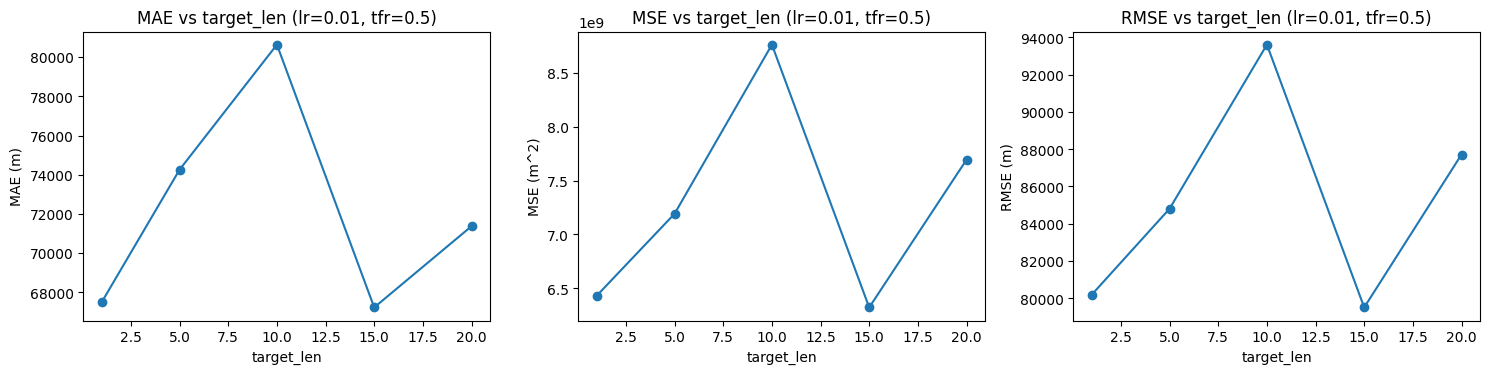

In [33]:
fixed_lr = 0.01
fixed_tfr = 0.5

sub = results_df[(results_df["learning_rate"] == fixed_lr) & (results_df["teacher_forcing_ratio"] == fixed_tfr)].sort_values("target_len")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(sub["target_len"], sub["MAE_m"], marker="o")
axes[0].set_title(f"MAE vs target_len (lr={fixed_lr}, tfr={fixed_tfr})")
axes[0].set_xlabel("target_len")
axes[0].set_ylabel("MAE (m)")

axes[1].plot(sub["target_len"], sub["MSE_m2"], marker="o")
axes[1].set_title(f"MSE vs target_len (lr={fixed_lr}, tfr={fixed_tfr})")
axes[1].set_xlabel("target_len")
axes[1].set_ylabel("MSE (m^2)")

axes[2].plot(sub["target_len"], sub["RMSE_m"], marker="o")
axes[2].set_title(f"RMSE vs target_len (lr={fixed_lr}, tfr={fixed_tfr})")
axes[2].set_xlabel("target_len")
axes[2].set_ylabel("RMSE (m)")

plt.tight_layout()
plt.show()

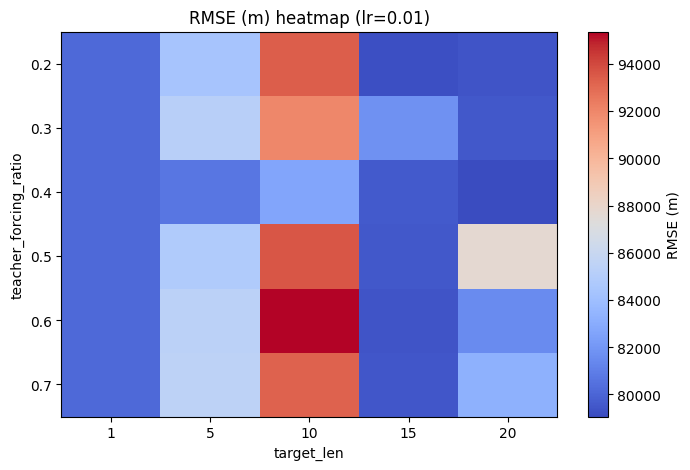

In [43]:
fixed_lr = 0.01
sub = results_df[results_df["learning_rate"] == fixed_lr]

pivot = sub.pivot_table(
    index="teacher_forcing_ratio",
    columns="target_len",
    values="RMSE_m",
    aggfunc="mean"
).sort_index()

plt.figure(figsize=(8, 5))
plt.imshow(pivot.values, aspect="auto", cmap="coolwarm")
plt.xticks(range(len(pivot.columns)), pivot.columns)
plt.yticks(range(len(pivot.index)), pivot.index)
plt.xlabel("target_len")
plt.ylabel("teacher_forcing_ratio")
plt.title(f"RMSE (m) heatmap (lr={fixed_lr})")
plt.colorbar(label="RMSE (m)")
plt.show()

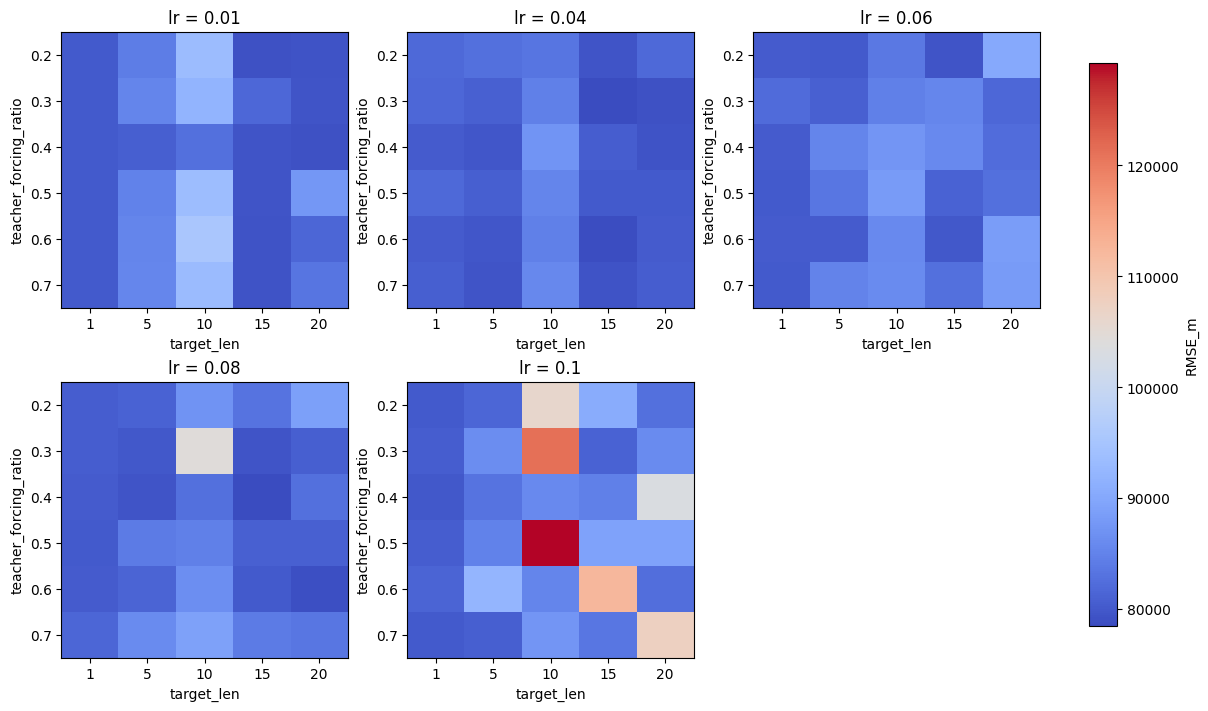

In [45]:
metric_col = "RMSE_m"   # change to "MAE_m" or "MSE_m2" if you want
lrs = sorted(results_df["learning_rate"].unique())

# Build pivots first so we can share the same color scale across all subplots
pivots = []
for lr in lrs:
    sub = results_df[results_df["learning_rate"] == lr]
    piv = sub.pivot_table(
        index="teacher_forcing_ratio",
        columns="target_len",
        values=metric_col,
        aggfunc="mean"
    ).sort_index()
    pivots.append(piv)

# Shared color limits across all LRs (makes comparisons fair)
all_vals = np.concatenate([p.values.flatten() for p in pivots])
vmin, vmax = np.nanmin(all_vals), np.nanmax(all_vals)

# Layout (e.g., 2 rows x 3 cols for 5 learning rates)
n = len(lrs)
ncols = 3
nrows = int(np.ceil(n / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(4*ncols, 3.5*nrows), constrained_layout=True)
axes = np.array(axes).reshape(-1)

for i, (lr, piv) in enumerate(zip(lrs, pivots)):
    ax = axes[i]
    im = ax.imshow(piv.values, aspect="auto", cmap="coolwarm", vmin=vmin, vmax=vmax)

    ax.set_title(f"lr = {lr}")
    ax.set_xticks(range(len(piv.columns)))
    ax.set_xticklabels(piv.columns)
    ax.set_yticks(range(len(piv.index)))
    ax.set_yticklabels(piv.index)

    ax.set_xlabel("target_len")
    ax.set_ylabel("teacher_forcing_ratio")

# Turn off any unused axes
for j in range(i + 1, len(axes)):
    axes[j].axis("off")

# One shared colorbar
cbar = fig.colorbar(im, ax=axes[:n], shrink=0.9)
cbar.set_label(metric_col)

plt.show()

In [63]:
results_df.sort_values("MAE_m", ascending=True).head()

,target_len,teacher_forcing_ratio,learning_rate,MAE_m,MSE_m2,RMSE_m,best_val_loss,model_path,per_step_MAE_m,per_step_RMSE_m
96,15,0.3,0.04,65609.773438,6.156370e+09,78462.538322,0.301631,grid_models\seq2seq_tlen15_tfr0.3_lr0.04.pt,"62329.94,62500.68,63052.10,63568.84,64086.07,6...","74451.76,74654.34,75330.09,75945.05,76555.77,7..."
103,15,0.4,0.08,65724.273438,6.177482e+09,78596.960755,0.306313,grid_models\seq2seq_tlen15_tfr0.4_lr0.08.pt,"62953.77,62731.30,63523.53,63460.59,64050.14,6...","75111.99,74919.03,75254.95,75838.66,76535.53,7..."
111,15,0.6,0.04,65901.851562,6.196593e+09,78718.439009,0.299860,grid_models\seq2seq_tlen15_tfr0.6_lr0.04.pt,"62502.50,65831.30,63329.75,63645.02,64140.22,6...","74585.88,78800.65,75623.92,75949.52,76523.89,7..."
126,20,0.3,0.04,66239.304688,6.279068e+09,79240.568196,0.309662,grid_models\seq2seq_tlen20_tfr0.3_lr0.04.pt,"81769.45,62903.34,62365.84,62623.89,62871.77,6...","93119.79,74817.54,74469.76,74837.02,75201.63,7..."
131,20,0.4,0.04,66422.070312,6.295800e+09,79346.079424,0.304520,grid_models\seq2seq_tlen20_tfr0.4_lr0.04.pt,"83894.86,63098.54,62592.41,62841.68,63065.77,6...","96156.63,75284.06,74641.37,74941.97,75273.02,7..."


In [46]:
results_df.sort_values("MSE_m2").head()

,target_len,teacher_forcing_ratio,learning_rate,MAE_m,MSE_m2,RMSE_m,best_val_loss,model_path,per_step_MAE_m,per_step_RMSE_m
96,15,0.3,0.04,65609.773438,6.156370e+09,78462.538322,0.301631,grid_models\seq2seq_tlen15_tfr0.3_lr0.04.pt,"62329.94,62500.68,63052.10,63568.84,64086.07,6...","74451.76,74654.34,75330.09,75945.05,76555.77,7..."
103,15,0.4,0.08,65724.273438,6.177482e+09,78596.960755,0.306313,grid_models\seq2seq_tlen15_tfr0.4_lr0.08.pt,"62953.77,62731.30,63523.53,63460.59,64050.14,6...","75111.99,74919.03,75254.95,75838.66,76535.53,7..."
111,15,0.6,0.04,65901.851562,6.196593e+09,78718.439009,0.299860,grid_models\seq2seq_tlen15_tfr0.6_lr0.04.pt,"62502.50,65831.30,63329.75,63645.02,64140.22,6...","74585.88,78800.65,75623.92,75949.52,76523.89,7..."
143,20,0.6,0.08,66604.906250,6.244072e+09,79019.443481,0.296625,grid_models\seq2seq_tlen20_tfr0.6_lr0.08.pt,"63538.84,63852.97,63645.16,64039.07,64244.09,6...","75261.04,74658.37,75426.89,76149.80,76484.89,7..."
130,20,0.4,0.01,66791.812500,6.250966e+09,79063.050890,0.305668,grid_models\seq2seq_tlen20_tfr0.4_lr0.01.pt,"63554.88,63801.67,64067.19,64342.70,64567.17,6...","74812.84,75137.59,75493.51,75873.45,76215.52,7..."


In [47]:
results_df.sort_values("RMSE_m").head()

,target_len,teacher_forcing_ratio,learning_rate,MAE_m,MSE_m2,RMSE_m,best_val_loss,model_path,per_step_MAE_m,per_step_RMSE_m
96,15,0.3,0.04,65609.773438,6.156370e+09,78462.538322,0.301631,grid_models\seq2seq_tlen15_tfr0.3_lr0.04.pt,"62329.94,62500.68,63052.10,63568.84,64086.07,6...","74451.76,74654.34,75330.09,75945.05,76555.77,7..."
103,15,0.4,0.08,65724.273438,6.177482e+09,78596.960755,0.306313,grid_models\seq2seq_tlen15_tfr0.4_lr0.08.pt,"62953.77,62731.30,63523.53,63460.59,64050.14,6...","75111.99,74919.03,75254.95,75838.66,76535.53,7..."
111,15,0.6,0.04,65901.851562,6.196593e+09,78718.439009,0.299860,grid_models\seq2seq_tlen15_tfr0.6_lr0.04.pt,"62502.50,65831.30,63329.75,63645.02,64140.22,6...","74585.88,78800.65,75623.92,75949.52,76523.89,7..."
143,20,0.6,0.08,66604.906250,6.244072e+09,79019.443481,0.296625,grid_models\seq2seq_tlen20_tfr0.6_lr0.08.pt,"63538.84,63852.97,63645.16,64039.07,64244.09,6...","75261.04,74658.37,75426.89,76149.80,76484.89,7..."
130,20,0.4,0.01,66791.812500,6.250966e+09,79063.050890,0.305668,grid_models\seq2seq_tlen20_tfr0.4_lr0.01.pt,"63554.88,63801.67,64067.19,64342.70,64567.17,6...","74812.84,75137.59,75493.51,75873.45,76215.52,7..."


In [26]:
R_EARTH_M = 6371000.0
KNOTS_TO_MPS = 0.514444

def haversine_m(lat1, lon1, lat2, lon2):
    """
    lat/lon in degrees, returns meters. Works with numpy arrays.
    """
    lat1 = np.deg2rad(lat1); lon1 = np.deg2rad(lon1)
    lat2 = np.deg2rad(lat2); lon2 = np.deg2rad(lon2)

    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = np.sin(dlat/2.0)**2 + np.cos(lat1)*np.cos(lat2)*np.sin(dlon/2.0)**2
    c = 2*np.arctan2(np.sqrt(a), np.sqrt(1-a))
    return R_EARTH_M * c

def metrics_meters_from_latlon(pred_deg, true_deg):
    """
    pred_deg, true_deg: numpy arrays of shape (T, N, 2) in degrees.
    Computes per-step great-circle error in meters, then MAE/MSE/RMSE over all steps+samples.
    """
    pred_lat = pred_deg[..., 0]
    pred_lon = pred_deg[..., 1]
    true_lat = true_deg[..., 0]
    true_lon = true_deg[..., 1]

    err_m = haversine_m(true_lat, true_lon, pred_lat, pred_lon)  # (T, N)

    mae = float(np.mean(np.abs(err_m)))
    mse = float(np.mean(err_m**2))
    rmse = float(np.sqrt(mse))

    per_step_mae = np.mean(np.abs(err_m), axis=1)   # (T,)
    per_step_rmse = np.sqrt(np.mean(err_m**2, axis=1))
    return mae, mse, rmse, per_step_mae, per_step_rmse, err_m

In [27]:
def dead_reckoning_predict_from_sincos(X, target_len, idx_lat, idx_lon, idx_sog, idx_cog_sin, idx_cog_cos, dt_seconds=60.0):
    Xn = X.detach().cpu().numpy()
    last = Xn[-1]

    lat0 = last[:, idx_lat]
    lon0 = last[:, idx_lon]
    sog_kn = last[:, idx_sog]
    cog_rad = np.arctan2(last[:, idx_cog_sin], last[:, idx_cog_cos])  # radians

    sog_mps = sog_kn * KNOTS_TO_MPS
    step_dist_m = sog_mps * dt_seconds

    pred = np.zeros((target_len, Xn.shape[1], 2), dtype=np.float64)

    lat = lat0.copy()
    lon = lon0.copy()

    for t in range(target_len):
        d_north = step_dist_m * np.cos(cog_rad)
        d_east  = step_dist_m * np.sin(cog_rad)

        dlat = d_north / 111000.0
        dlon = d_east  / (111000.0 * np.cos(np.deg2rad(lat)))

        lat = lat + dlat
        lon = lon + dlon

        pred[t, :, 0] = lat
        pred[t, :, 1] = lon

    return pred

In [29]:
target_len = 15

Y_test = Y_test_dict[target_len]          # shape (15, N, 2)
X_test = X_test_dict[target_len]          # shape (seq_len, N, F)

pred_dr = dead_reckoning_predict_from_sincos(
    X_test, target_len,
    idx_lat=0, idx_lon=1, idx_sog=2,
    idx_cog_sin=4, idx_cog_cos=5,
    dt_seconds=60.0
)

true = Y_test.detach().cpu().numpy()      # (15, N, 2)

mae_m, mse_m2, rmse_m, per_step_mae, per_step_rmse, err_m = metrics_meters_from_latlon(pred_dr, true)
print("Dead Reckoning baseline:")
print(" MAE (m):", mae_m)
print(" MSE (m^2):", mse_m2)
print(" RMSE (m):", rmse_m)
print(err_m)

Dead Reckoning baseline:
 MAE (m): 38921.121813001315
 MSE (m^2): 4310886704.358847
 RMSE (m): 65657.34311072028
[[  2873.10615638   1916.79927846   1180.70701837 ...   2417.40620319
    2401.75633743 198974.46097594]
 [  4780.54062406   3097.85548052   3611.30147969 ...   4819.69601847
  196581.5435411  198703.51879802]
 [  5952.21507791   5528.69720056   5019.85793687 ... 194171.28049789
  196311.70144646 196856.90963656]
 ...
 [ 24930.60785137  24251.07758699  24110.59800105 ... 164021.87718969
  162641.14551364 163380.98014051]
 [ 27002.20222645  26030.81650019  26096.61848729 ... 160163.09113924
  161000.42246379 163982.53737899]
 [ 28772.57624766  28017.19703323  27944.56215223 ... 158515.01241118
  161602.0667807  162831.84866116]]


In [ ]:
top_lstm = results_df.sort_values("MAE_m", ascending=True)
print(" MAE (m):", min(top_lstm["MAE_m"]))
print(" MSE (m^2):", min(top_lstm["MSE_m2"]))
print(" RMSE (m):", min(top_lstm["RMSE_m"]))

65609.7734375
 MAE (m): 65609.7734375
 MSE (m^2): 6156369920.0
 RMSE (m): 78462.53832243767


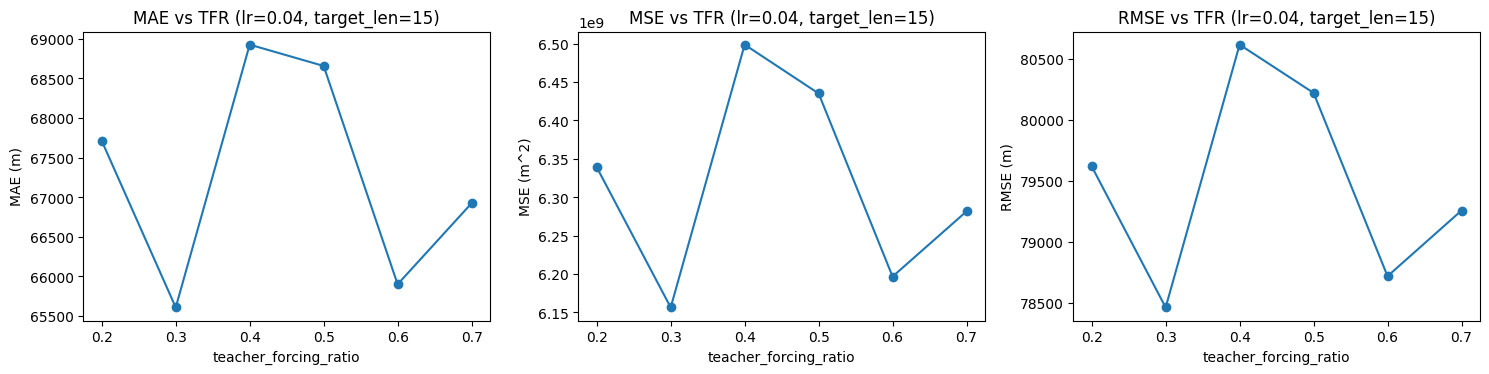

In [42]:
fixed_len = 15
fixed_lr = 0.04

sub = results_df[
    (results_df["learning_rate"] == fixed_lr) &
    (results_df["target_len"] == fixed_len)
].sort_values("teacher_forcing_ratio")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(sub["teacher_forcing_ratio"], sub["MAE_m"], marker="o")
axes[0].set_title(f"MAE vs TFR (lr={fixed_lr}, target_len={fixed_len})")
axes[0].set_xlabel("teacher_forcing_ratio")
axes[0].set_ylabel("MAE (m)")

axes[1].plot(sub["teacher_forcing_ratio"], sub["MSE_m2"], marker="o")
axes[1].set_title(f"MSE vs TFR (lr={fixed_lr}, target_len={fixed_len})")
axes[1].set_xlabel("teacher_forcing_ratio")
axes[1].set_ylabel("MSE (m^2)")

axes[2].plot(sub["teacher_forcing_ratio"], sub["RMSE_m"], marker="o")
axes[2].set_title(f"RMSE vs TFR (lr={fixed_lr}, target_len={fixed_len})")
axes[2].set_xlabel("teacher_forcing_ratio")
axes[2].set_ylabel("RMSE (m)")

plt.tight_layout()
plt.show()